In [1]:
cd /mnt/home/al2644/research/projects/perturb-r

/mnt/home/al2644/research/projects/perturb-r


/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import random
from fractions import Fraction
from typing import List, Tuple
import pandas as pd
from datasets import Dataset

import pandas as pd 
import os 

from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

import seaborn as sns

from datasets import load_dataset, load_from_disk
import numpy as np
import json

from utils.corrupt_num import *
from utils.chunk_r import *

python benchmark_eval.py --model_name qwen/qwq-32b:free --nick_name QwQ-32B --tokenizer_name Qwen/QwQ-32B --dataset_name_or_path ./data/allmath --split_name test --sample_size 10 --output_dir ./results/allmath/benchmark --tensor_parallel_size 8 --gpu_memory_utilization 0.85 --dtype bfloat16 --max_tokens 32768 --temperature 0.6 --top_p 0.95 --top_k 20 --sample_k 8 --client_name openrouter --overwrite True

# Check Eval Dataset

In [22]:
path = "./data/allmath/"
dataset = load_from_disk(path)['test']
eval_df = dataset.to_pandas()

In [24]:
eval_df['source'].value_counts()

source
minerva_math    272
math500         134
aime25           30
aime24           30
Name: count, dtype: int64

In [26]:
eval_df

,problem,solution,source
0,Every morning Aya goes for a $9$-kilometer-lon...,204,aime24
1,Let $ABC$ be a triangle inscribed in circle $\...,113,aime24
2,Each vertex of a regular octagon is independen...,371,aime24
3,Define $f(x)=|| x|-\tfrac{1}{2}|$ and $g(x)=||...,385,aime24
4,Let $p$ be the least prime number for which th...,110,aime24
...,...,...,...
461,A baseball has diameter $=7.4 \mathrm{~cm}$. a...,\[\n\begin{aligned}\nD_{\text {ball }} &=0.074...,minerva_math
462,Preamble: Consider the Particle in an Infinite...,\[\n\langle E\rangle =\boxed{\frac{1}{3} E_{1}...,minerva_math
463,Preamble: Consider the Particle in an Infinite...,Since the only eigenergies are $E_{1}$ and $E_...,minerva_math
464,Preamble: Evaluate the following integrals for...,\[\n\begin{gathered}\n\int \psi_{22}^{*}\left(...,minerva_math


In [121]:
path= '../rlvr/Qwen2.5-Eval/evaluation/data/math500/test.jsonl'
def read_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            yield json.loads(line)
            
dataset = pd.DataFrame(list(read_jsonl(path)))

In [123]:
dataset['level'].value_counts()

level
5    134
4    128
3    105
2     90
1     43
Name: count, dtype: int64

# Reasoning Benchmark Eval

In [8]:
root = "./results/allmath/benchmark/"
for fname in os.listdir(root):
    if 'api' not in fname:
        print(fname)
        df = pd.read_pickle(os.path.join(root, fname))
        print(f"Accuracy: {df['correct'].mean()}")

Qwen3-1.7B.pickle
Accuracy: 0.6856364678899083
R1-Distill-Qwen-32B.pickle
Accuracy: 0.7532970183486238


In [4]:
root = "./results/allmath/benchmark/"
df=pd.read_pickle(os.path.join(root, 'Qwen3-1.7B.pickle'))

In [17]:
from reward_score import qwen_math
import importlib; importlib.reload(qwen_math)

<module 'reward_score.qwen_math' from '/mnt/home/al2644/research/projects/perturb-r/reward_score/qwen_math.py'>

In [18]:
result_df = qwen_math.eval_dataframe(df, 'solution', 'response')

Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 6976/6976 [02:53<00:00, 40.29it/s]


In [20]:
result_df.groupby('source')['is_correct'].mean()

source
aime24          0.345833
aime25          0.283333
amc23           0.743750
math500         0.627750
minerva_math    0.506434
Name: is_correct, dtype: float64

In [136]:
print(minerva_df['solution'].iloc[1])

Start with:
\[
s=\alpha f \text {, }
\]
where $s$ is the diameter of the image, $f$ the focal length, and $\alpha$ the angular diameter of the planet. For the values given in the problem:
\[
s=\frac{45}{3600} \frac{\pi}{180} 7200=\boxed{1.6} \mathrm{~cm}
\]


In [139]:
print(minerva_df['response'].iloc[1])

<think>
Okay, so I need to find the diameter of the image of a planet on the telescope's image at the focus, given the telescope's diameter, the focal length, and the angular diameter of the planet. Let me think about how to approach this.

First, I remember that when dealing with telescopes and optics, the angular diameter of an object is related to its actual diameter and the distance at which it's observed. The formula that connects these is the small angle approximation, right? Which is θ ≈ d / D, where θ is the angular diameter in radians, d is the actual diameter, and D is the distance to the object. But here, the problem is about the image size on the telescope's focal plane, so I need to relate the angular size of the planet to the image diameter on the telescope.

Wait, the telescope has a diameter of 6.5 meters, so that's the diameter of the main mirror. The focal length is 72 meters. The angular diameter of the planet is given as 45 arcseconds. I need to find the image diame

In [120]:
stats = df.groupby('problem').agg({'correct': 'max', 'source': 'first'}).reset_index()
stats.groupby('source')['correct'].mean()

source
aime24          0.700000
aime25          0.433333
amc23           0.900000
math500         0.928000
minerva_math    0.518382
Name: correct, dtype: float64

In [99]:
from math_verify import parse, verify

def reverify(row):
    
    solution = row['solution']
    response = row['response']
    
    if '</think>' not in response:
        return False

    if '\\boxed' not in response:
        return False

    gold = parse(solution)
    answer = response.split('</think>')[-1]
    answer = parse(answer)

    return verify(gold, answer) 

In [100]:
results = []
for i, row in df.iterrows():
    print('row: ', i)
    results.append(reverify(row))
df['math-verify'] = results

row:  0
row:  1
row:  2
row:  3
row:  4
row:  5
row:  6
row:  7
row:  8
row:  9
row:  10
row:  11
row:  12
row:  13
row:  14
row:  15
row:  16
row:  17
row:  18
row:  19
row:  20
row:  21
row:  22
row:  23
row:  24
row:  25
row:  26
row:  27
row:  28
row:  29
row:  30
row:  31
row:  32
row:  33
row:  34
row:  35
row:  36
row:  37
row:  38
row:  39
row:  40
row:  41
row:  42
row:  43
row:  44
row:  45
row:  46
row:  47
row:  48
row:  49
row:  50
row:  51
row:  52
row:  53
row:  54
row:  55
row:  56
row:  57
row:  58
row:  59
row:  60
row:  61
row:  62
row:  63
row:  64
row:  65
row:  66
row:  67
row:  68
row:  69
row:  70
row:  71
row:  72
row:  73
row:  74
row:  75
row:  76
row:  77
row:  78
row:  79
row:  80
row:  81
row:  82
row:  83
row:  84
row:  85
row:  86
row:  87
row:  88
row:  89
row:  90
row:  91
row:  92
row:  93
row:  94
row:  95
row:  96
row:  97
row:  98
row:  99
row:  100
row:  101
row:  102
row:  103
row:  104
row:  105
row:  106
row:  107
row:  108
row:  109
row:  110


row:  896
row:  897
row:  898
row:  899
row:  900
row:  901
row:  902
row:  903
row:  904
row:  905
row:  906
row:  907
row:  908
row:  909
row:  910
row:  911
row:  912
row:  913
row:  914
row:  915
row:  916
row:  917
row:  918
row:  919
row:  920
row:  921
row:  922
row:  923
row:  924
row:  925
row:  926
row:  927
row:  928
row:  929
row:  930
row:  931
row:  932
row:  933
row:  934
row:  935
row:  936
row:  937
row:  938
row:  939
row:  940
row:  941
row:  942
row:  943
row:  944
row:  945
row:  946
row:  947
row:  948
row:  949
row:  950
row:  951
row:  952
row:  953
row:  954
row:  955
row:  956
row:  957
row:  958
row:  959
row:  960
row:  961
row:  962
row:  963
row:  964
row:  965
row:  966
row:  967
row:  968
row:  969
row:  970
row:  971
row:  972
row:  973
row:  974
row:  975
row:  976
row:  977
row:  978
row:  979
row:  980
row:  981
row:  982
row:  983
row:  984
row:  985
row:  986
row:  987
row:  988
row:  989
row:  990
row:  991
row:  992
row:  993
row:  994
row:  995


row:  1793
row:  1794
row:  1795
row:  1796
row:  1797
row:  1798
row:  1799
row:  1800
row:  1801
row:  1802
row:  1803
row:  1804
row:  1805
row:  1806
row:  1807
row:  1808
row:  1809
row:  1810
row:  1811
row:  1812
row:  1813
row:  1814
row:  1815
row:  1816
row:  1817
row:  1818
row:  1819
row:  1820
row:  1821
row:  1822
row:  1823
row:  1824
row:  1825
row:  1826
row:  1827
row:  1828
row:  1829
row:  1830
row:  1831
row:  1832
row:  1833
row:  1834
row:  1835
row:  1836
row:  1837
row:  1838
row:  1839
row:  1840
row:  1841
row:  1842
row:  1843
row:  1844
row:  1845
row:  1846
row:  1847
row:  1848
row:  1849
row:  1850
row:  1851
row:  1852
row:  1853
row:  1854
row:  1855
row:  1856
row:  1857
row:  1858
row:  1859
row:  1860
row:  1861
row:  1862
row:  1863
row:  1864
row:  1865
row:  1866
row:  1867
row:  1868
row:  1869
row:  1870
row:  1871
row:  1872
row:  1873
row:  1874
row:  1875
row:  1876
row:  1877
row:  1878
row:  1879
row:  1880
row:  1881
row:  1882
row:  1883

row:  2636
row:  2637
row:  2638
row:  2639
row:  2640
row:  2641
row:  2642
row:  2643
row:  2644
row:  2645
row:  2646
row:  2647
row:  2648
row:  2649
row:  2650
row:  2651
row:  2652
row:  2653
row:  2654
row:  2655
row:  2656
row:  2657
row:  2658
row:  2659
row:  2660
row:  2661
row:  2662
row:  2663
row:  2664
row:  2665
row:  2666
row:  2667
row:  2668
row:  2669
row:  2670
row:  2671
row:  2672
row:  2673
row:  2674
row:  2675
row:  2676
row:  2677
row:  2678
row:  2679
row:  2680
row:  2681
row:  2682
row:  2683
row:  2684
row:  2685
row:  2686
row:  2687
row:  2688
row:  2689
row:  2690
row:  2691
row:  2692
row:  2693
row:  2694
row:  2695
row:  2696
row:  2697
row:  2698
row:  2699
row:  2700
row:  2701
row:  2702
row:  2703
row:  2704
row:  2705
row:  2706
row:  2707
row:  2708
row:  2709
row:  2710
row:  2711
row:  2712
row:  2713
row:  2714
row:  2715
row:  2716
row:  2717
row:  2718
row:  2719
row:  2720
row:  2721
row:  2722
row:  2723
row:  2724
row:  2725
row:  2726

row:  3447
row:  3448
row:  3449
row:  3450
row:  3451
row:  3452
row:  3453
row:  3454
row:  3455
row:  3456
row:  3457
row:  3458
row:  3459
row:  3460
row:  3461
row:  3462
row:  3463
row:  3464
row:  3465
row:  3466
row:  3467
row:  3468
row:  3469
row:  3470
row:  3471
row:  3472
row:  3473
row:  3474
row:  3475
row:  3476
row:  3477
row:  3478
row:  3479
row:  3480
row:  3481
row:  3482
row:  3483
row:  3484
row:  3485
row:  3486
row:  3487
row:  3488
row:  3489
row:  3490
row:  3491
row:  3492
row:  3493
row:  3494
row:  3495
row:  3496
row:  3497
row:  3498
row:  3499
row:  3500
row:  3501
row:  3502
row:  3503
row:  3504
row:  3505
row:  3506
row:  3507
row:  3508
row:  3509
row:  3510
row:  3511
row:  3512
row:  3513
row:  3514
row:  3515
row:  3516
row:  3517
row:  3518
row:  3519
row:  3520
row:  3521
row:  3522
row:  3523
row:  3524
row:  3525
row:  3526
row:  3527
row:  3528
row:  3529
row:  3530
row:  3531
row:  3532
row:  3533
row:  3534
row:  3535
row:  3536
row:  3537

...

row:  6393
row:  6394
row:  6395
row:  6396
row:  6397
row:  6398
row:  6399
row:  6400
row:  6401
row:  6402
row:  6403
row:  6404
row:  6405
row:  6406
row:  6407
row:  6408
row:  6409
row:  6410
row:  6411
row:  6412
row:  6413
row:  6414
row:  6415
row:  6416
row:  6417
row:  6418
row:  6419
row:  6420
row:  6421
row:  6422
row:  6423
row:  6424
row:  6425
row:  6426
row:  6427
row:  6428
row:  6429
row:  6430
row:  6431
row:  6432
row:  6433
row:  6434
row:  6435
row:  6436
row:  6437
row:  6438
row:  6439
row:  6440
row:  6441


Error during comparison
Traceback (most recent call last):
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 809, in compare_single_extraction_wrapper
    return compare_single_extraction(g, t)
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/utils.py", line 51, in wrapper
    return func(*args, **kwargs)
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 789, in compare_single_extraction
    return sympy_expr_eq(
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 667, in sympy_expr_eq
    return sympy_compare_relational(gold, pred, float_rounding, numeric_precision)
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 344, in sympy_compare_relational
    if sympy_solve_and_compare(gold, pred, float_rounding, numeric

row:  6442
row:  6443
row:  6444
row:  6445
row:  6446
row:  6447
row:  6448
row:  6449
row:  6450
row:  6451
row:  6452
row:  6453
row:  6454
row:  6455
row:  6456
row:  6457
row:  6458
row:  6459
row:  6460
row:  6461
row:  6462
row:  6463
row:  6464
row:  6465
row:  6466
row:  6467
row:  6468
row:  6469
row:  6470
row:  6471
row:  6472
row:  6473
row:  6474
row:  6475
row:  6476
row:  6477
row:  6478
row:  6479
row:  6480
row:  6481
row:  6482
row:  6483
row:  6484
row:  6485
row:  6486


Error during comparison
Traceback (most recent call last):
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 809, in compare_single_extraction_wrapper
    return compare_single_extraction(g, t)
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/utils.py", line 51, in wrapper
    return func(*args, **kwargs)
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 789, in compare_single_extraction
    return sympy_expr_eq(
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 667, in sympy_expr_eq
    return sympy_compare_relational(gold, pred, float_rounding, numeric_precision)
  File "/mnt/home/al2644/miniconda3/envs/rlvr_eval/lib/python3.10/site-packages/math_verify/grader.py", line 344, in sympy_compare_relational
    if sympy_solve_and_compare(gold, pred, float_rounding, numeric

row:  6487
row:  6488
row:  6489
row:  6490
row:  6491
row:  6492
row:  6493
row:  6494
row:  6495
row:  6496
row:  6497
row:  6498
row:  6499
row:  6500
row:  6501
row:  6502
row:  6503
row:  6504
row:  6505
row:  6506
row:  6507
row:  6508
row:  6509
row:  6510
row:  6511
row:  6512
row:  6513
row:  6514
row:  6515
row:  6516
row:  6517
row:  6518
row:  6519
row:  6520
row:  6521
row:  6522
row:  6523
row:  6524
row:  6525
row:  6526
row:  6527
row:  6528
row:  6529
row:  6530
row:  6531
row:  6532
row:  6533
row:  6534
row:  6535
row:  6536
row:  6537
row:  6538
row:  6539
row:  6540
row:  6541
row:  6542
row:  6543
row:  6544
row:  6545
row:  6546
row:  6547
row:  6548
row:  6549
row:  6550
row:  6551
row:  6552
row:  6553
row:  6554
row:  6555
row:  6556
row:  6557
row:  6558
row:  6559
row:  6560
row:  6561
row:  6562
row:  6563
row:  6564
row:  6565
row:  6566
row:  6567
row:  6568
row:  6569
row:  6570
row:  6571
row:  6572
row:  6573
row:  6574
row:  6575
row:  6576
row:  6577

In [101]:
df.groupby('source')['math-verify'].mean()

source
aime24          0.341667
aime25          0.283333
amc23           0.737500
math500         0.713750
minerva_math    0.407169
Name: math-verify, dtype: float64

In [112]:
df.iloc[4976]

problem        Consider the following "mixing problem." A tan...
solution       The differential equation for $y(t)$ is $\boxe...
source                                              minerva_math
response       <think>\nOkay, so I need to figure out the dif...
correct                                                      0.0
if_answer                                                   True
math-verify                                                False
Name: 4976, dtype: object

In [143]:
example = df.loc[5536]

In [95]:
# row:  5536 5537

# disagree_df = df[df['correct'] != df['math-verify']]
# example = disagree_df.iloc[0]

In [110]:
example

problem        Write (but don't solve) the equation of motion...
solution       From force balance, we can derive the equation...
source                                              minerva_math
response       <think>\nOkay, so I need to write the equation...
correct                                                      0.0
if_answer                                                   True
math-verify                                                False
Name: 5536, dtype: object

In [146]:
print(example['solution'])
print('correct?: ', example['correct'])
# print('math-verify: ', example['math-verify'])
print('-'*70)
print(example['response'])

From force balance, we can derive the equation of motion. Choosing the system variable system variable $\theta(t)$ with polar coordinates, we don't need to care about tension on the rod and centrifugal force.
We can use the relation between torque and angular momentum to immediately write down the equation for $\theta(t)$:
\[
m l^{2} \ddot{\theta}(t)-m g l \sin \theta(t)=f(t) l \cos \theta(t) .
\]
Dividing both sides by $l$ gives:
\[
\boxed{m l \ddot{\theta}(t)-m g \sin \theta(t)=f(t) \cos \theta(t)} .
\]
Note that inertia of the mass with respect to the rotation axis is $m l^{2}$. It is a non linear differential equation because it has $\sin \theta(t)$ term.
correct?:  0.0
----------------------------------------------------------------------
<think>
Okay, so I need to write the equation of motion for a pendulum with a mass m attached to a rigid rod of length l, suspended from the ceiling. The system is free to rotate in a single vertical plane. The input is a horizontal external forc

In [154]:
sol = example['solution']
answer = example['response'].split('</think>')[-1]

In [151]:
parsed_gt = extract_answer(sol, 'minerva_math')

In [158]:
parsed_answer = extract_answer(answer, 'minerva_math')

In [159]:
parsed_gt

'ml\\ddot{\\theta}(t)-mg\\sin\\theta(t)=f(t)\\cos\\theta(t)'

In [160]:
parsed_answer

'I\\ddot{\\theta}(t)=-mgl\\sin\\theta(t)-f(t)l\\cos\\theta(t)'

In [164]:
math_equal(parsed_gt, parsed_answer)

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generat

False

In [124]:
from qwen_eval.eval_utils.utils.grader import check_is_correct
from qwen_eval.eval_utils.utils.parser import extract_answer

def evaluate_prediction(row) -> bool:
    response = row['response']
    gold_answer = row['solution']
    
    if '</think>' not in response:
        return 0.
    model_pred = response.split('</think>')[-1]
    extracted_answer = extract_answer(model_pred)
    
    return check_is_correct(extracted_answer, gold_answer)

,problem,solution,source,response,correct,if_answer


In [39]:
results = []
for i, row in df.iterrows():
    print(i)
    results.append(evaluate_prediction(row))
    
df['qwen-verify'] = results

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1259
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1260
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1261
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1262
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1497
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1498
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1499
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1500
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1501
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1502
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
1503
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9

2080
2081
2082
2083
2084
2085
2086
2087
2088
2089
2090
2091
2092
2093
2094
2095
2096
2097
2098
2099
2100
2101
2102
2103
2104
2105
2106
2107
2108
2109
2110
2111
2112
2113
2114
2115
2116
2117
2118
2119
2120
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
2121
2122
2123
2124
2125
2126
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
2127
2128
2129
2130
2131
2132
2133
2134
2135
2136
2137
2138
2139
2140
2141
2142
2143
2144
2145
2146
2147
2148
2149
2150
2151
2152
2153
2154
2155
2156
2157
2158
2159
2160
2161
2162
2163
2164
2165
2166
2167
2168
2169
2170
2171
2172
2173
2174
2175


ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
2755
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
2756
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime a

...

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6542
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6543
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6544
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runt

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6564
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6565
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime a

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6594
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6595
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6596
ANTLR runt

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6623
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6624
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime a

ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6653
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6654
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6655
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
ANTLR runtime and generated code versions disagree: 4.9.3!=4.7.2
6656
6657


In [43]:
df['qwen-verify'] = df['qwen-verify'].map({True: 1., False: 0.})

In [58]:
example = df[df['correct'] != df['qwen-verify']].iloc[10]

In [59]:
print(example['solution'])
print('correct: ', example['correct'])
print('qwen-verify: ', example['qwen-verify'])
print('if_answer: ', example['if_answer'])
print('-'*70)
print(example['response'])

\text{Evelyn}
correct:  0.0
qwen-verify:  1.0
if_answer:  True
----------------------------------------------------------------------
<think>
Okay, so I need to figure out which student has the greatest average speed based on the graph provided. Let me start by recalling that average speed is calculated by dividing the total distance traveled by the total time taken. 

First, I should look at the Asymptote code to understand the graph. The graph has vertical axes for distance and horizontal axes for time. The vertical axis is labeled "distance" and the horizontal axis is labeled "time". The graph is drawn with vertical lines from (i,0) to (i,6) for i from 1 to 7, so that's 7 vertical lines, each 1 unit apart, and the vertical axis goes up to 6 units. The horizontal axis has labels from 0 to 8, with some ticks at 0, 1, 2, 3, 4, 5, 6, 7, 8. There's also a horizontal line at the bottom labeled "O" (origin) and a vertical line at -0.5, 0 to 8, which is probably the time axis. The vertical 

In [62]:
df=df[df['source'] == 'minerva_math']

In [78]:
example = df.sample(n=1).iloc[0]

In [79]:
example

problem        Given the ordinary differential equation $\ddo...
solution       First, notice that both $x(t)=e^{a t}$ and $x(...
source                                              minerva_math
response       <think>\nOkay, so I need to solve this differe...
correct                                                      1.0
if_answer                                                   True
math-verify                                                  1.0
qwen-verify                                                  0.0
Name: 5246, dtype: object

In [84]:
example['problem']

'Given the ordinary differential equation $\\ddot{x}-a^{2} x=0$, where $a$ is a nonzero real-valued constant, find a solution $x(t)$ to this equation such that $x(0) = 1$ and $\\dot{x}(0)=0$.'

In [86]:
parse(example['solution'])

[(exp(a*t) + exp(-a*t))/2, '\\frac{1}{2}(\\exp{a*t} + \\exp{-a*t})']

In [85]:
print(parse(example['response']))

[cosh(a*t), '\\cosh(at)']


### visualization

In [77]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

root = "./results/deepmath/benchmark/"
steps = [200, 400, 600, 800, 1000, 1200, 1400, 1890]

# template → label (keep keys concise for legends)
templates = {
    "stage0-sft"          : "Qwen2.5-1.5B-DeepMath-level1-4-sft-stage0-step{step}.pickle"
}

# pick linestyles for the three model variants
dashes_map = {"stage0-sft": ""}

In [78]:
def collect_records():
    """Return tidy DataFrame with columns:
       step, model, level, acc, answer_rate
    """
    out = []
    for model, tmpl in templates.items():
        for step in steps:
            path = os.path.join(root, tmpl.format(step=step))
            df   = pd.read_pickle(path)
            g    = groupby_level(df).reset_index()     # cols: level, acc, answer_rate
            g["step"]  = step
            g["model"] = model
            out.append(g)
    return pd.concat(out, ignore_index=True)

tidy        = collect_records()

In [81]:
tidy

,difficulty,correct,step,model
0,3.0,41.0,200,stage0-sft
1,3.5,16.5,200,stage0-sft
2,4.0,18.0,200,stage0-sft
3,4.5,23.0,200,stage0-sft
4,5.0,15.0,200,stage0-sft
...,...,...,...,...
99,7.0,30.0,1890,stage0-sft
100,7.5,28.0,1890,stage0-sft
101,8.0,26.0,1890,stage0-sft
102,8.5,24.0,1890,stage0-sft


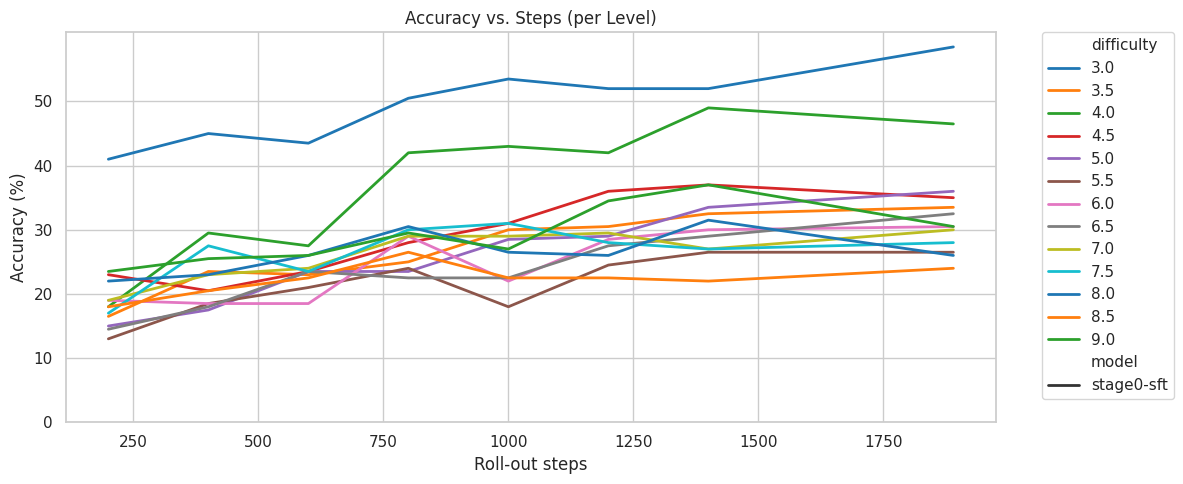

In [79]:

# ------------------------------------------------------------------
# PLOTTING  ---------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.0)

def lineplot(metric, ylabel, title):
    ax = sns.lineplot(
        data   = tidy,
        x      = "step",
        y      = metric,
        hue    = "difficulty",      # color ↔ difficulty level
        style  = "model",      # linestyle ↔ model variant
        dashes = dashes_map,   # enforce our line styles
        palette= "tab10",
        linewidth = 2.0,
    )
    ax.set(
        xlabel = "Roll-out steps",
        ylabel = ylabel,
        title  = title,
    )
#     ax.set_xticks([50, 100, 150, 200, 250])
    ax.set_yticks(range(0, 60, 10)) 
    
    ax.legend(bbox_to_anchor=(1.05,1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()

plt.figure(figsize=(12,5))
lineplot("correct", "Accuracy (%)", "Accuracy vs. Steps (per Level)")
plt.show()

In [89]:
df

,difficulty,topic,subtopic,problem,solution,task,response,correct,if_answer,token_counts
0,3.0,Mathematics -> Algebra -> Algebra -> Algebraic...,0,Simplify $(2x - 5)(x + 7) - (x + 5)(2x - 1)$.,-30,math,"<think>\nOkay, so I need to simplify this expr...",1.0,True,2251
1,3.0,Mathematics -> Applied Mathematics -> Math Wor...,1,Ten families have an average of 2 children per...,2.5,math,"<think>\nOkay, so I need to figure out the ave...",1.0,True,1396
2,3.0,Mathematics -> Geometry -> Plane Geometry -> T...,5,Andrea notices that the 40-foot tree next to h...,60,math,"<think>\nOkay, so I need to figure out how tal...",1.0,True,1150
3,3.0,Mathematics -> Number Theory -> Prime Numbers,6,Find the sum of the first 9 prime numbers.,100,math,"<think>\nOkay, so I need to find the sum of th...",0.0,True,7256
4,3.0,Mathematics -> Number Theory -> Congruences,6,Find one integer solution to the Diophantine e...,"(3, 1, -1)",math,"<think>\nOkay, so I need to find one integer s...",0.0,False,16383
...,...,...,...,...,...,...,...,...,...,...
2595,9.0,Mathematics -> Discrete Mathematics -> Logic,4,Determine the least cardinality \( \kappa \) s...,\aleph_1,math,"<think>\nOkay, so I need to figure out the lea...",0.0,True,7669
2596,9.0,Mathematics -> Other,7,Identify the name of the smallest ordinal numb...,\omega_1,math,"<think>\nOkay, so I need to figure out the nam...",0.0,True,6695
2597,9.0,Mathematics -> Applied Mathematics -> Statisti...,1,Evaluate the variance of the stochastic integr...,2t^3,math,"<think>\nOkay, so I need to find the variance ...",0.0,True,9810
2598,9.0,Mathematics -> Algebra -> Abstract Algebra -> ...,0,Determine the class group of the complement of...,0,math,"<think>\nOkay, so I need to find the class gro...",0.0,True,3929


In [ ]:
def groupby_level (df):
    stats = df.groupby('level')['correct'].mean()
    answer_rate = df.groupby('level')['if_answer'].mean()
    result = pd.DataFrame({'acc': stats * 100, 'answer_rate': answer_rate * 100})
    return result

### visualization

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

root = "./results/countdown/benchmark/"
steps = [50, 100, 150, 200, 250]

# template → label (keep keys concise for legends)
templates = {
    "stage2"          : "Qwen2.5-3B-countdown-level5-stage2-{step}steps.pickle",
    "stage2-rand-thought"      : "Qwen2.5-3B-countdown-level5-random_thought-stage2-{step}steps.pickle",
    "stage2-rand-thought-only" : "Qwen2.5-3B-countdown-level5-random_thought-only-stage2-{step}steps.pickle",
}

# pick linestyles for the three model variants
dashes_map = {"stage2": "",         # solid
              "stage2-rand-thought": (2,2),  # dotted
              "stage2-rand-thought-only": (4,2)}  # dashed

baseline_files = {
    "sft-stage0"   : "Qwen2.5-3B-distill-countdown-level3-4-1epoch-stage0.pickle",
    "stage1-rl"  : "Qwen2.5-3B-grpo-countdown-level4-5-1epoch-stage1.pickle",
}

# give every *baseline* a distinct (long-dash) line style
dashes_map.update({k: (6,2) for k in baseline_files})   # e.g. – – – –

dashes_map.update({
    "sft-stage0" : (1, 1, 3, 1),   #   ·  — ·   —  (dash–dot)
    "stage1-rl"  : (8, 3, 2, 3),   #   ———   — ———   (long-short-long)
})

# ------------------------------------------------------------------
# 1.  LOAD EVERYTHING INTO ONE TIDY FRAME --------------------------
# ------------------------------------------------------------------
def collect_static(baseline_files):
    """Duplicate each baseline’s per-level metric across *all* steps so
       Seaborn treats them as horizontal lines.
    """
    out = []
    for model, rel_path in baseline_files.items():
        df  = pd.read_pickle(os.path.join(root, rel_path))
        g   = groupby_level(df).reset_index()            # level, acc, answer_rate
        for step in steps:                               # broadcast → every x-pos
            g_step = g.copy()
            g_step["step"]  = step
            g_step["model"] = model
            out.append(g_step)
    return pd.concat(out, ignore_index=True)

tidy_static = collect_static(baseline_files)

def collect_records():
    """Return tidy DataFrame with columns:
       step, model, level, acc, answer_rate
    """
    out = []
    for model, tmpl in templates.items():
        for step in steps:
            path = os.path.join(root, tmpl.format(step=step))
            df   = pd.read_pickle(path)
            g    = groupby_level(df).reset_index()     # cols: level, acc, answer_rate
            g["step"]  = step
            g["model"] = model
            out.append(g)
    return pd.concat(out, ignore_index=True)

tidy        = collect_records()
tidy_static = collect_static(baseline_files)
tidy        = pd.concat([tidy, tidy_static], ignore_index=True)   # ← merge


# ------------------------------------------------------------------
# PLOTTING  ---------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.0)

def lineplot(metric, ylabel, title):
    ax = sns.lineplot(
        data   = tidy,
        x      = "step",
        y      = metric,
        hue    = "level",      # color ↔ difficulty level
        style  = "model",      # linestyle ↔ model variant
        dashes = dashes_map,   # enforce our line styles
        palette= "tab10",
        linewidth = 2.0,
    )
    ax.set(
        xlabel = "Roll-out steps",
        ylabel = ylabel,
        title  = title,
    )
    ax.set_xticks([50, 100, 150, 200, 250])
    ax.set_yticks(range(0, 101, 10)) 
    
    ax.legend(bbox_to_anchor=(1.05,1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()

plt.figure(figsize=(12,5))
lineplot("acc", "Accuracy (%)", "Accuracy vs. Steps (per Level)")
plt.show()

In [92]:
acc = tidy[tidy['difficulty'].isin([7., 8.])]
acc

,difficulty,correct,step,model
8,7.0,19.0,200,stage0-sft
10,8.0,22.0,200,stage0-sft
21,7.0,23.0,400,stage0-sft
23,8.0,23.0,400,stage0-sft
34,7.0,24.0,600,stage0-sft
36,8.0,26.0,600,stage0-sft
47,7.0,29.0,800,stage0-sft
49,8.0,30.5,800,stage0-sft
60,7.0,29.0,1000,stage0-sft
62,8.0,26.5,1000,stage0-sft


# Corrupted Numbers

In [840]:
pwd

'/home/al2644/research/codebase/reasoning/perturb-r'

In [841]:
root = "./results/countdown/corrupt_numbers/"

def has_answer (response):
    if "<answer>" in response:
        return 1.
    else:
        return 0.
    
for fname in os.listdir(root):
    if 'still_correct' not in fname:
        print(fname)
        df = pd.read_pickle(os.path.join(root, fname))
        print(f"Accuracy: {df['still_correct'].mean()}")

Qwen2.5-3B-distill-countdown-level3-4-1epoch.pickle
Accuracy: 0.5202702702702703
Qwen2.5-3B-grpo-countdown-level4-5-1epoch.pickle
Accuracy: 0.5934684684684685


In [842]:
df = pd.read_pickle(os.path.join(root, "Qwen2.5-3B-grpo-countdown-level4-5-1epoch.pickle"))


In [844]:
df.groupby("start_pos")["still_correct"].mean()

start_pos
0.00    0.184685
0.25    0.720721
0.50    0.752252
0.75    0.716216
Name: still_correct, dtype: float64

In [854]:
df.groupby("start_pos")["if_answer"].mean()

start_pos
0.00    0.409910
0.25    0.765766
0.50    0.788288
0.75    0.995495
Name: if_answer, dtype: float64

In [858]:
example = df[(df["start_pos"] == 0.5) & (df["still_correct"] == 0.) & (df["if_answer"] == True)].iloc[0]

In [859]:
print(example["prompt"])

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Please reason and answer the following question. Using the numbers [13, 10, 27, 92, 31], create an equation that equals 742. You can only use basic arithmetic operations (+, -, *, /) in the expression and each number should be used exactly once. You should report the answer equation expression in <answer> </answer> tags, for example <answer> (1 + 2) / 3 </answer>.<|im_end|>
<|im_start|>assistant
<think>


Okay, let's see. I need to use the numbers 13, 10, 27, 92, and 31 exactly once each, with basic operations to make 742. Hmm. Let me think. First, maybe I should try combining some numbers to get closer to 742. Since 742 is a relatively large number, maybe multiplication is involved here. Let me check the numbers: 92 is


the largest, then 31, 27, 10, 13.


Let me think about possible multiplications. If I multiply 92 by something, maybe? Let's see. 92 * 8 is 736, which is close to 742. But how do I get 8 from t

In [860]:
print(example["post_corruption_response"])

 

Alternatively, think of 92 * 10 = 920. Then 920 - 27 = 893. 893 - 13 = 880. 880 + 31 = 911. No, that's not helpful. 

Alternatively, 92 * 27 = 2484. Then 2484 - 31 = 2453. 2453 - 13 = 2440. 2440 + 10 = 2450. Not 742. 

Alternatively, 92 * 13 = 1204. Then 1204 - 31 = 1173. 1173 - 27 = 1146. 1146 - 10 = 1136. That's way over. 

Alternatively, 92 * 31 = 2852. Then 2852 - 27 = 2825. 2825 - 13 = 2812. 2812 - 10 = 2802. No. 

Alternatively, 31 * 10 = 310. Then 310 + 27 = 337. 337 + 92 = 429. 429 + 13 = 442. No. 

Wait, maybe 27 * 13 = 351. Then 351 * 2 = 702. Then 702 + 40 = 742. How to get 40 from 92 and 31. 92 - 31 = 61. Not 40. 92 - 31 is 61, then 61 - 10 = 51. No. 

Alternatively, 27 * 10 = 270. Then 270 + 92 = 362. 362 * something? 362 * 2 is 724. Then 724 + 18 = 742. How to get 18 from 13 and 31. 31 - 13 = 18. Oh! Wait! That's possible. 

So let's see: (27 * 10) + 92 = 362. Then 362 + (31 - 13) = 362 + 18 = 380. No, that's not. Wait, but if I do 27 * 10 + 92 + (31 -13) = 362 + 92 + 

In [695]:
wrong_answer[['level', 'type']].value_counts()

level  type         
5      post_</think>    80
6      post_</think>    21
5      pre_</think>     17
6      pre_</think>      5
Name: count, dtype: int64

# Distractor Injection

In [796]:
root = "./results/countdown/inject_distractor/"

def has_answer (response):
    if "<answer>" in response:
        return 1.
    else:
        return 0.
    
for fname in os.listdir(root):
    print(fname)
    df = pd.read_pickle(os.path.join(root, fname))
    print(f"Original Accuracy: {df['original_correct'].mean()}")
    print(f"Distractor Accuracy: {df['distractor_correct'].mean()}")

df = pd.read_pickle(os.path.join(root, "Qwen2.5-3B-grpo-countdown-level4-5-1epoch.pickle"))

Qwen2.5-3B-distill-countdown-level3-4-1epoch.pickle
Original Accuracy: 0.3626237623762376
Distractor Accuracy: 0.5006188118811881
Qwen2.5-3B-grpo-countdown-level4-5-1epoch.pickle
Original Accuracy: 0.46163366336633666
Distractor Accuracy: 0.47277227722772275


In [797]:
df = pd.read_pickle(os.path.join(root, "Qwen2.5-3B-distill-countdown-level3-4-1epoch.pickle"))
df.groupby("prefix_ratio")[["original_correct", "distractor_correct"]].mean()

,original_correct,distractor_correct
prefix_ratio,,
0.00,0.047030,0.816832
0.25,0.544554,0.292079
0.50,0.462871,0.400990
0.75,0.396040,0.492574


In [798]:
df = pd.read_pickle(os.path.join(root, "Qwen2.5-3B-grpo-countdown-level4-5-1epoch.pickle"))
df.groupby("prefix_ratio")[["original_correct", "distractor_correct"]].mean()

,original_correct,distractor_correct
prefix_ratio,,
0.00,0.009901,0.938119
0.25,0.670792,0.252475
0.50,0.613861,0.309406
0.75,0.551980,0.391089


In [799]:
df

,nums,target,example_solution,problem,level,task,original_response,reasoning_chunks,prefix_ratio,distractor_ratio,distract_nums,distract_target,distract_reasoning,prompt,post_distraction_response,original_correct,distractor_correct
0,"[50, 77, 64, 67, 73]",331,(((73+50)+64)+(67+77)),Please reason and answer the following questio...,5,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.0,0.25,"[86, 91, 87, 68, 77, 66]",165,"<think>\nOkay, let's see. I need to use the nu...",<|im_start|>system\nYou are a helpful assistan...,"Not sure. Alternatively, 87 - 66 = 21. 91 - 7...",0.0,1.0
1,"[50, 77, 64, 67, 73]",331,(((73+50)+64)+(67+77)),Please reason and answer the following questio...,5,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.0,0.5,"[20, 73, 85, 82, 33]",89,"<think>\nOkay, let's see. I need to use the nu...",<|im_start|>system\nYou are a helpful assistan...,33 + 85 is 118. 118 - 82 is 36. 36 +73 is 109...,0.0,1.0
2,"[50, 77, 64, 67, 73]",331,(((73+50)+64)+(67+77)),Please reason and answer the following questio...,5,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.0,0.75,"[20, 73, 85, 82, 33]",89,"<think>\nOkay, let's see. I need to use the nu...",<|im_start|>system\nYou are a helpful assistan...,So the answer would be that expression. So th...,0.0,1.0
3,"[50, 77, 64, 67, 73]",331,(((73+50)+64)+(67+77)),Please reason and answer the following questio...,5,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.0,1.0,"[74, 51, 64, 31, 48]",104,"<think>\nOkay, let's see. I need to use the nu...",<|im_start|>system\nYou are a helpful assistan...,The answer should be in <answer> tags. So <an...,0.0,1.0
4,"[50, 77, 64, 67, 73]",331,(((73+50)+64)+(67+77)),Please reason and answer the following questio...,5,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.25,0.25,"[25, 87, 42, 34, 57]",63,"<think>\nOkay, let's see. I need to use each o...",<|im_start|>system\nYou are a helpful assistan...,"87 - 57 is 30, then 30 - 25 is 5, not helpful....",1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,"[84, 3, 85, 12, 51, 9]",307,(((9+85)+12)+((3*84)-51)),Please reason and answer the following questio...,6,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.5,1.0,"[75, 96, 96, 56, 68]",129,"<think>\nOkay, let's see. I need to use each o...",<|im_start|>system\nYou are a helpful assistan...,"Therefore, the equation is 96 - 75 + 96 + 68 ...",1.0,0.0
1612,"[84, 3, 85, 12, 51, 9]",307,(((9+85)+12)+((3*84)-51)),Please reason and answer the following questio...,6,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.75,0.25,"[74, 51, 64, 31, 48]",104,"<think>\nOkay, let's see. I need to use each o...",<|im_start|>system\nYou are a helpful assistan...,Maybe (64 - 51) = 13. Then 13 + 48 = 61. Then...,1.0,0.0
1613,"[84, 3, 85, 12, 51, 9]",307,(((9+85)+12)+((3*84)-51)),Please reason and answer the following questio...,6,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.75,0.5,"[71, 93, 76, 10, 96]",184,"<think>\nOkay, let's see. I need to use each o...",<|im_start|>system\nYou are a helpful assistan...,204 is not 184. What if I do 76 + 93 = 169. 16...,0.0,0.0
1614,"[84, 3, 85, 12, 51, 9]",307,(((9+85)+12)+((3*84)-51)),Please reason and answer the following questio...,6,countdown,"<think>\nOkay, let's see. I need to use each o...","[<think>\nOkay, let's see. I need to use each ...",0.75,0.75,"[17, 76, 59, 23, 18]",41,"<think>\nOkay, let's see. I need to use each o...",<|im_start|>system\nYou are a helpful assistan

In [802]:
idx = 7
example = df.iloc[idx]
prefix_ratio, distractor_ratio = example["prefix_ratio"], example["distractor_ratio"]
print("prefix_ratio: ", prefix_ratio)
print("distractor_ratio: ", distractor_ratio)
prompt, response, original_correct, distractor_correct = example["prompt"], example["post_distraction_response"], example["original_correct"], example["distractor_correct"]

print("original correct?: ", original_correct)
print("distract correct?: ", distractor_correct)

prefix_ratio:  0.25
distractor_ratio:  1.0
original correct?:  0.0
distract correct?:  1.0


In [803]:
print(prompt)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Please reason and answer the following question. Using the numbers [50, 77, 64, 67, 73], create an equation that equals 331. You can only use basic arithmetic operations (+, -, *, /) in the expression and each number should be used exactly once. You should report the answer equation expression in <answer> </answer> tags, for example <answer> (1 + 2) / 3 </answer>.<|im_end|>
<|im_start|>assistant
<think>
Okay, let's see. I need to use each of the numbers 50, 77, 64, 67, and 73 exactly once with basic operations to make 331. Hmm. Let me think about possible combinations.Wait. Let me think again: Okay, let's see. I need to use the numbers 86, 91, 87, 68, 77, and 66 exactly once each, with basic arithmetic operations to make 165. Hmm, first, maybe I should think about possible combinations. Let me list the numbers again: 86, 91, 87, 68, 77, 66. All have to be used once. The target is 165.What's 165? Let me think abo

In [804]:
print(response)

 Which is the same as the previous grouping. Alternatively, written as (66 + 77) + (86 - 68) + (91 - 87). Either way, the operations are all allowed. Let me check again if the order is correct. Let me compute the expression step by step. 66 + 77 is 143. Then 143 + 86 is 229. Then subtract 68: 229 - 68 = 161. Then add 91: 161 + 91 = 252. Then subtract 87: 252 - 87 = 165. Correct. So that's the right equation.
</think>

<answer> 66 + 77 + 86 - 68 + 91 - 87 </answer>



In [ ]:
evals
    0. same set of stress tests for both math and countdown
    1. if observations on countdown and math are consistent
    2. if the corruption happens in the first chunk
    3. check the eval results for sft 3 epoch

In [ ]:
training todo:
    
    mix original question and corrupted prefix
    1. collect offline rl prefix ==> rl (save checkpoints for later eval)
    2. rl on same flops ==> same number of problems (assuming problems i.i.d)
    3. 1st rl collect for rejection sampling
    
    
generalization:
    1. different types of corruption (distractor injection, just wrong answer at the end)
    2. different degrees of digit corruption
    3. different task complexity
    


In [ ]:
generate more level 5, 6, 7 questions 50K each
use r1 to generate corrupted prefix + collect recovery + not recover (50 50)

we can launch 2 first

# Check test set

In [42]:
df1 = pd.read_parquet("../rlvr/data/train/countdown_level5_random_thought_30k/test.parquet")
df2 = pd.read_parquet("../rlvr/data/train/countdown_level5_random_thought_only_15k/test.parquet")

In [43]:
df1

,data_source,prompt,ability,reward_model,extra_info
0,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [50, 77, 64, 67, ...","{'index': 0, 'level': '6', 'split': 'test'}"
1,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [88, 84, 11, 71, ...","{'index': 1, 'level': '6', 'split': 'test'}"
2,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [35, 48, 94, 46, ...","{'index': 2, 'level': '6', 'split': 'test'}"
3,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [18, 58, 64, 42, ...","{'index': 3, 'level': '6', 'split': 'test'}"
4,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [37, 18, 51, 39, ...","{'index': 4, 'level': '6', 'split': 'test'}"
...,...,...,...,...,...
295,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [95, 38, 13, 72, ...","{'index': 295, 'level': '7', 'split': 'test'}"
296,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [51, 100, 99, 91,...","{'index': 296, 'level': '7', 'split': 'test'}"
297,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [44, 2, 3, 41, 85...","{'index': 297, 'level': '7', 'split': 'test'}"
298,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [55, 20, 64, 3, 4...","{'index': 298, 'level': '7', 'split': 'test'}"


In [44]:
df2

,data_source,prompt,ability,reward_model,extra_info
0,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [50, 77, 64, 67, ...","{'index': 0, 'level': '6', 'split': 'test'}"
1,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [88, 84, 11, 71, ...","{'index': 1, 'level': '6', 'split': 'test'}"
2,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [35, 48, 94, 46, ...","{'index': 2, 'level': '6', 'split': 'test'}"
3,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [18, 58, 64, 42, ...","{'index': 3, 'level': '6', 'split': 'test'}"
4,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [37, 18, 51, 39, ...","{'index': 4, 'level': '6', 'split': 'test'}"
...,...,...,...,...,...
295,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [95, 38, 13, 72, ...","{'index': 295, 'level': '7', 'split': 'test'}"
296,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [51, 100, 99, 91,...","{'index': 296, 'level': '7', 'split': 'test'}"
297,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [44, 2, 3, 41, 85...","{'index': 297, 'level': '7', 'split': 'test'}"
298,countdown,[{'content': 'Please reason and answer the fol...,math,"{'ground_truth': {'numbers': [55, 20, 64, 3, 4...","{'index': 298, 'level': '7', 'split': 'test'}"


# Minerva

In [140]:
import random
import regex
import re
import sympy
from latex2sympy2 import latex2sympy
from typing import TypeVar, Iterable, List, Union, Any, Dict
from word2number import w2n
from utils import *


def _fix_fracs(string):
    substrs = string.split("\\frac")
    new_str = substrs[0]
    if len(substrs) > 1:
        substrs = substrs[1:]
        for substr in substrs:
            new_str += "\\frac"
            if len(substr) > 0 and substr[0] == "{":
                new_str += substr
            else:
                try:
                    assert len(substr) >= 2
                except:
                    return string
                a = substr[0]
                b = substr[1]
                if b != "{":
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}{" + b + "}" + post_substr
                    else:
                        new_str += "{" + a + "}{" + b + "}"
                else:
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}" + b + post_substr
                    else:
                        new_str += "{" + a + "}" + b
    string = new_str
    return string


def _fix_a_slash_b(string):
    if len(string.split("/")) != 2:
        return string
    a = string.split("/")[0]
    b = string.split("/")[1]
    try:
        if "sqrt" not in a:
            a = int(a)
        if "sqrt" not in b:
            b = int(b)
        assert string == "{}/{}".format(a, b)
        new_string = "\\frac{" + str(a) + "}{" + str(b) + "}"
        return new_string
    except:
        return string


def _fix_sqrt(string):
    _string = re.sub(r"\\sqrt(\w+)", r"\\sqrt{\1}", string)
    return _string


def convert_word_number(text: str) -> str:
    try:
        text = str(w2n.word_to_num(text))
    except:
        pass
    return text


# units mainly from MathQA
unit_texts = [
    "east",
    "degree",
    "mph",
    "kmph",
    "ft",
    "m sqaure",
    " m east",
    "sq m",
    "deg",
    "mile",
    "q .",
    "monkey",
    "prime",
    "ratio",
    "profit of rs",
    "rd",
    "o",
    "gm",
    "p . m",
    "lb",
    "tile",
    "per",
    "dm",
    "lt",
    "gain",
    "ab",
    "way",
    "west",
    "a .",
    "b .",
    "c .",
    "d .",
    "e .",
    "f .",
    "g .",
    "h .",
    "t",
    "a",
    "h",
    "no change",
    "men",
    "soldier",
    "pie",
    "bc",
    "excess",
    "st",
    "inches",
    "noon",
    "percent",
    "by",
    "gal",
    "kmh",
    "c",
    "acre",
    "rise",
    "a . m",
    "th",
    "π r 2",
    "sq",
    "mark",
    "l",
    "toy",
    "coin",
    "sq . m",
    "gallon",
    "° f",
    "profit",
    "minw",
    "yr",
    "women",
    "feet",
    "am",
    "pm",
    "hr",
    "cu cm",
    "square",
    "v â € ™",
    "are",
    "rupee",
    "rounds",
    "cubic",
    "cc",
    "mtr",
    "s",
    "ohm",
    "number",
    "kmph",
    "day",
    "hour",
    "minute",
    "min",
    "second",
    "man",
    "woman",
    "sec",
    "cube",
    "mt",
    "sq inch",
    "mp",
    "∏ cm ³",
    "hectare",
    "more",
    "sec",
    "unit",
    "cu . m",
    "cm 2",
    "rs .",
    "rs",
    "kg",
    "g",
    "month",
    "km",
    "m",
    "cm",
    "mm",
    "apple",
    "liter",
    "loss",
    "yard",
    "pure",
    "year",
    "increase",
    "decrease",
    "d",
    "less",
    "Surface",
    "litre",
    "pi sq m",
    "s .",
    "metre",
    "meter",
    "inch",
]

unit_texts.extend([t + "s" for t in unit_texts])


def strip_string(string, skip_unit=False):
    string = str(string).strip()
    # linebreaks
    string = string.replace("\n", "")

    # right "."
    string = string.rstrip(".")

    # remove inverse spaces
    # replace \\ with \
    string = string.replace("\\!", "")
    # string = string.replace("\\ ", "")
    # string = string.replace("\\\\", "\\")

    # matrix
    string = re.sub(r"\\begin\{array\}\{.*?\}", r"\\begin{pmatrix}", string)
    string = re.sub(r"\\end\{array\}", r"\\end{pmatrix}", string)
    string = string.replace("bmatrix", "pmatrix")

    # replace tfrac and dfrac with frac
    string = string.replace("tfrac", "frac")
    string = string.replace("dfrac", "frac")
    string = (
        string.replace("\\neq", "\\ne")
        .replace("\\leq", "\\le")
        .replace("\\geq", "\\ge")
    )

    # remove \left and \right
    string = string.replace("\\left", "")
    string = string.replace("\\right", "")
    string = string.replace("\\{", "{")
    string = string.replace("\\}", "}")

    # Remove unit: miles, dollars if after is not none
    _string = re.sub(r"\\text{.*?}$", "", string).strip()
    if _string != "" and _string != string:
        # print("Warning: unit not removed: '{}' -> '{}'".format(string, _string))
        string = _string

    if not skip_unit:
        # Remove unit: texts
        for _ in range(2):
            for unit_text in unit_texts:
                # use regex, the prefix should be either the start of the string or a non-alphanumeric character
                # the suffix should be either the end of the string or a non-alphanumeric character
                _string = re.sub(r"(^|\W)" + unit_text + r"($|\W)", r"\1\2", string)
                if _string != "":
                    string = _string

    # Remove circ (degrees)
    string = string.replace("^{\\circ}", "")
    string = string.replace("^\\circ", "")

    # remove dollar signs
    string = string.replace("\\$", "")
    string = string.replace("$", "")
    string = string.replace("\\(", "").replace("\\)", "")

    # convert word number to digit
    string = convert_word_number(string)

    # replace "\\text{...}" to "..."
    string = re.sub(r"\\text\{(.*?)\}", r"\1", string)
    for key in ["x=", "y=", "z=", "x\\in", "y\\in", "z\\in", "x\\to", "y\\to", "z\\to"]:
        string = string.replace(key, "")
    string = string.replace("\\emptyset", r"{}")
    string = string.replace("(-\\infty,\\infty)", "\\mathbb{R}")

    # remove percentage
    string = string.replace("\\%", "")
    string = string.replace("\%", "")
    string = string.replace("%", "")

    # " 0." equivalent to " ." and "{0." equivalent to "{." Alternatively, add "0" if "." is the start of the string
    string = string.replace(" .", " 0.")
    string = string.replace("{.", "{0.")

    # cdot
    # string = string.replace("\\cdot", "")
    if (
        string.startswith("{")
        and string.endswith("}")
        and string.isalnum()
        or string.startswith("(")
        and string.endswith(")")
        and string.isalnum()
        or string.startswith("[")
        and string.endswith("]")
        and string.isalnum()
    ):
        string = string[1:-1]

    # inf
    string = string.replace("infinity", "\\infty")
    if "\\infty" not in string:
        string = string.replace("inf", "\\infty")
    string = string.replace("+\\inity", "\\infty")

    # and
    string = string.replace("and", "")
    string = string.replace("\\mathbf", "")

    # use regex to remove \mbox{...}
    string = re.sub(r"\\mbox{.*?}", "", string)

    # quote
    string.replace("'", "")
    string.replace('"', "")

    # i, j
    if "j" in string and "i" not in string:
        string = string.replace("j", "i")

    # replace a.000b where b is not number or b is end, with ab, use regex
    string = re.sub(r"(\d+)\.0*([^\d])", r"\1\2", string)
    string = re.sub(r"(\d+)\.0*$", r"\1", string)

    # if empty, return empty string
    if len(string) == 0:
        return string
    if string[0] == ".":
        string = "0" + string

    # to consider: get rid of e.g. "k = " or "q = " at beginning
    if len(string.split("=")) == 2:
        if len(string.split("=")[0]) <= 2:
            string = string.split("=")[1]

    string = _fix_sqrt(string)
    string = string.replace(" ", "")

    # \frac1b or \frac12 --> \frac{1}{b} and \frac{1}{2}, etc. Even works with \frac1{72} (but not \frac{72}1). Also does a/b --> \\frac{a}{b}
    string = _fix_fracs(string)

    # NOTE: X/Y changed to \frac{X}{Y} in dataset, but in simple cases fix in case the model output is X/Y
    string = _fix_a_slash_b(string)

    return string


def extract_multi_choice_answer(pred_str):
    # TODO: SFT models
    if "Problem:" in pred_str:
        pred_str = pred_str.split("Problem:", 1)[0]
    pred_str = pred_str.replace("choice is", "answer is")
    patt = regex.search(r"answer is \(?(?P<ans>[abcde])\)?", pred_str.lower())
    if patt is not None:
        return patt.group("ans").upper()
    return "placeholder"


direct_answer_trigger_for_fewshot = ("choice is", "answer is")


def choice_answer_clean(pred: str):
    pred = pred.strip("\n")

    # Determine if this is ICL, if so, use \n\n to split the first chunk.
    ICL = False
    for trigger in direct_answer_trigger_for_fewshot:
        if pred.count(trigger) > 1:
            ICL = True
    if ICL:
        pred = pred.split("\n\n")[0]

    # Split the trigger to find the answer.
    preds = re.split("|".join(direct_answer_trigger_for_fewshot), pred)
    if len(preds) > 1:
        answer_flag = True
        pred = preds[-1]
    else:
        answer_flag = False

    pred = pred.strip("\n").rstrip(".").rstrip("/").strip(" ").lstrip(":")

    # Clean the answer based on the dataset
    tmp = re.findall(r"\b(A|B|C|D|E)\b", pred.upper())
    if tmp:
        pred = tmp
    else:
        pred = [pred.strip().strip(".")]

    if len(pred) == 0:
        pred = ""
    else:
        if answer_flag:
            # choose the first element in list ...
            pred = pred[0]
        else:
            # choose the last e
            pred = pred[-1]

    # Remove the period at the end, again!
    pred = pred.rstrip(".").rstrip("/")

    return pred


def find_box(pred_str: str):
    ans = pred_str.split("boxed")[-1]
    if not ans:
        return ""
    if ans[0] == "{":
        stack = 1
        a = ""
        for c in ans[1:]:
            if c == "{":
                stack += 1
                a += c
            elif c == "}":
                stack -= 1
                if stack == 0:
                    break
                a += c
            else:
                a += c
    else:
        a = ans.split("$")[0].strip()
    return a


def clean_units(pred_str: str):
    """Clean the units in the number."""

    def convert_pi_to_number(code_string):
        code_string = code_string.replace("\\pi", "π")
        # Replace \pi or π not preceded by a digit or } with 3.14
        code_string = re.sub(r"(?<![\d}])\\?π", "3.14", code_string)
        # Replace instances where π is preceded by a digit but without a multiplication symbol, e.g., "3π" -> "3*3.14"
        code_string = re.sub(r"(\d)(\\?π)", r"\1*3.14", code_string)
        # Handle cases where π is within braces or followed by a multiplication symbol
        # This replaces "{π}" with "3.14" directly and "3*π" with "3*3.14"
        code_string = re.sub(r"\{(\\?π)\}", "3.14", code_string)
        code_string = re.sub(r"\*(\\?π)", "*3.14", code_string)
        return code_string

    pred_str = convert_pi_to_number(pred_str)
    pred_str = pred_str.replace("%", "/100")
    pred_str = pred_str.replace("$", "")
    pred_str = pred_str.replace("¥", "")
    pred_str = pred_str.replace("°C", "")
    pred_str = pred_str.replace(" C", "")
    pred_str = pred_str.replace("°", "")
    return pred_str


def extract_theoremqa_answer(pred: str, answer_flag: bool = True):
    if any([option in pred.lower() for option in ["yes", "true"]]):
        pred = "True"
    elif any([option in pred.lower() for option in ["no", "false"]]):
        pred = "False"
    elif any(
        [
            option in pred.lower()
            for option in ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
        ]
    ):
        pass
    else:
        # Some of the models somehow get used to boxed output from pre-training
        if "boxed" in pred:
            pred = find_box(pred)

        if answer_flag:
            # Extract the numbers out of the string
            pred = pred.split("=")[-1].strip()
            pred = clean_units(pred)
            try:
                tmp = str(latex2sympy(pred))
                pred = str(eval(tmp))
            except Exception:
                if re.match(r"-?[\d\.]+\s\D+$", pred):
                    pred = pred.split(" ")[0]
                elif re.match(r"-?[\d\.]+\s[^\s]+$", pred):
                    pred = pred.split(" ")[0]
        else:
            # desparate search over the last number
            preds = re.findall(r"-?\d*\.?\d+", pred)
            if len(preds) >= 1:
                pred = preds[-1]
            else:
                pred = ""

    return pred


def extract_answer(pred_str, data_name, use_last_number=True):
    pred_str = pred_str.replace("\u043a\u0438", "")
    if data_name in ["mmlu_stem", "sat_math", "aqua", "gaokao2023"]:
        # TODO check multiple choice
        return choice_answer_clean(pred_str)

    if "final answer is $" in pred_str and "$. I hope" in pred_str:
        # minerva_math
        tmp = pred_str.split("final answer is $", 1)[1]
        pred = tmp.split("$. I hope", 1)[0].strip()
    elif "boxed" in pred_str:
        ans = pred_str.split("boxed")[-1]
        if len(ans) == 0:
            return ""
        elif ans[0] == "{":
            stack = 1
            a = ""
            for c in ans[1:]:
                if c == "{":
                    stack += 1
                    a += c
                elif c == "}":
                    stack -= 1
                    if stack == 0:
                        break
                    a += c
                else:
                    a += c
        else:
            a = ans.split("$")[0].strip()
        pred = a
    elif "he answer is" in pred_str:
        pred = pred_str.split("he answer is")[-1].strip()
    elif "final answer is" in pred_str:
        pred = pred_str.split("final answer is")[-1].strip()
    elif "答案是" in pred_str:
        # Handle Chinese few-shot multiple choice problem answer extraction
        pred = pred_str.split("答案是")[1].strip().split("\n\n")[0].strip()
    else:  # use the last number
        if use_last_number:
            pattern = "-?\d*\.?\d+"
            pred = re.findall(pattern, pred_str.replace(",", ""))
            if len(pred) >= 1:
                pred = pred[-1]
            else:
                pred = ""
        else:
            pred = ""

    # choice answer
    if (
        data_name in ["sat_math", "aqua"]
        or "mmlu" in data_name
    ):
        tmp = re.findall(r"\b(A|B|C|D|E)\b", pred.upper())
        if tmp:
            pred = tmp[-1]
        else:
            pred = pred.strip().strip(".")

    # multiple line
    # pred = pred.split("\n")[0]
    pred = re.sub(r"\n\s*", "", pred)
    if pred != "" and pred[0] == ":":
        pred = pred[1:]
    if pred != "" and pred[-1] == ".":
        pred = pred[:-1]
    if pred != "" and pred[-1] == "/":
        pred = pred[:-1]
    pred = strip_string(pred, skip_unit=data_name in ["carp_en", "minerva_math"])
    return pred


STRIP_EXCEPTIONS = ["carp_en", "minerva_math"]


def parse_ground_truth(example: Dict[str, Any], data_name):
    if "gt_cot" in example and "gt" in example:
        if data_name in ["math"]:
            gt_ans = extract_answer(example["gt_cot"], data_name)
        elif data_name in STRIP_EXCEPTIONS:
            gt_ans = example["gt"]
        else:
            gt_ans = strip_string(example["gt"])
        return example["gt_cot"], gt_ans

    # parse ground truth
    if data_name in ["math", "minerva_math"]:
        gt_cot = example["solution"]
        gt_ans = extract_answer(gt_cot, data_name)
    elif data_name == "gsm8k":
        gt_cot, gt_ans = example["answer"].split("####")
    elif data_name == "svamp":
        gt_cot, gt_ans = example["Equation"], example["Answer"]
    elif data_name == "asdiv":
        gt_cot = example["formula"]
        gt_ans = re.sub(r"\(.*?\)", "", example["answer"])
    elif data_name == "mawps":
        gt_cot, gt_ans = None, example["target"]
    elif data_name == "tabmwp":
        gt_cot = example["solution"]
        gt_ans = example["answer"]
        if example["ans_type"] in ["integer_number", "decimal_number"]:
            if "/" in gt_ans:
                gt_ans = int(gt_ans.split("/")[0]) / int(gt_ans.split("/")[1])
            elif "," in gt_ans:
                gt_ans = float(gt_ans.replace(",", ""))
            elif "%" in gt_ans:
                gt_ans = float(gt_ans.split("%")[0]) / 100
            else:
                gt_ans = float(gt_ans)
    elif data_name == "carp_en":
        gt_cot, gt_ans = example["steps"], example["answer"]
    elif data_name == "mmlu_stem":
        abcd = "ABCD"
        gt_cot, gt_ans = None, abcd[example["answer"]]
    elif data_name == "sat_math":
        gt_cot, gt_ans = None, example["Answer"]
    elif data_name == "aqua":
        gt_cot, gt_ans = None, example["correct"]
    elif data_name in ["gaokao2023en", "college_math", "gaokao_math_cloze"]:
        gt_cot, gt_ans = None, example["answer"].replace("$", "").strip()
    elif data_name == "gaokao_math_qa":
        gt_cot, gt_ans = None, example["label"]
    elif data_name in ["gaokao2024_mix", "cn_middle_school"]:
        if len(example["choice_answer"]) > 0:
            gt_cot, gt_ans = None, example["choice_answer"]
        else:
            gt_cot, gt_ans = None, example["answer"]
    elif data_name == "olympiadbench":
        gt_cot, gt_ans = None, example["final_answer"][0].strip("$")
    elif data_name in [
        "aime24",
        "amc23",
        "cmath",
        "gaokao2024_I",
        "gaokao2024_II",
        "imo2024",
    ]:
        gt_cot, gt_ans = None, example["answer"]
    else:
        raise NotImplementedError(f"`{data_name}`")
    # post process
    gt_cot = str(gt_cot).strip()
    if data_name not in STRIP_EXCEPTIONS:
        gt_ans = strip_string(gt_ans, skip_unit=data_name == "carp_en")
    else:
        gt_ans = (
            gt_ans.replace("\\neq", "\\ne")
            .replace("\\leq", "\\le")
            .replace("\\geq", "\\ge")
        )
    return gt_cot, gt_ans


def parse_question(example, data_name):
    question = ""
    if data_name == "asdiv":
        question = f"{example['body'].strip()} {example['question'].strip()}"
    elif data_name == "svamp":
        body = example["Body"].strip()
        if not body.endswith("."):
            body = body + "."
        question = f'{body} {example["Question"].strip()}'
    elif data_name == "tabmwp":
        title_str = (
            f'regarding "{example["table_title"]}" ' if example["table_title"] else ""
        )
        question = f"Read the following table {title_str}and answer a question:\n"
        question += f'{example["table"]}\n{example["question"]}'
        if example["choices"]:
            question += (
                f' Please select from the following options: {example["choices"]}'
            )
    elif data_name == "carp_en":
        question = example["content"]
    elif data_name == "mmlu_stem":
        options = example["choices"]
        assert len(options) == 4
        for i, (label, option) in enumerate(zip("ABCD", options)):
            options[i] = f"({label}) {str(option).strip()}"
        options = " ".join(options)
        # question = f"{example['question'].strip()}\nWhat of the following is the right choice? Explain your answer.\n{options}"
        question = f"{example['question'].strip()}\nAnswer Choices: {options}"
    elif data_name == "sat_math":
        options = example["options"].strip()
        assert "A" == options[0]
        options = "(" + options
        for ch in "BCD":
            if f" {ch}) " in options:
                options = regex.sub(f" {ch}\) ", f" ({ch}) ", options)
        # question = f"{example['question'].strip()}\nWhat of the following is the right choice? Explain your answer.\n{options.strip()}"
        question = f"{example['question'].strip()}\nAnswer Choices: {options}"
    elif "aqua" in data_name:
        options = example["options"]
        choice = "(" + "(".join(options)
        choice = choice.replace("(", " (").replace(")", ") ").strip()
        choice = "\nAnswer Choices: " + choice
        question = example["question"].strip() + choice
    elif data_name == "gaokao_math_qa":
        options_dict = example["options"]
        options = []
        for key in options_dict:
            options.append(f"({key}) {options_dict[key]}")
        options = " ".join(options)
        question = f"{example['question'].strip()}\n选项: {options}"
    else:
        for key in ["question", "problem", "Question", "input"]:
            if key in example:
                question = example[key]
                break
    # assert question != ""
    # Yes or No question
    _, gt_ans = parse_ground_truth(example, data_name)
    if isinstance(gt_ans, str):
        gt_lower = gt_ans.lower()
        if gt_lower in ["true", "false"]:
            question += " (True or False)"
        if gt_lower in ["yes", "no"]:
            question += " (Yes or No)"
    return question.strip()


def run_execute(executor, result, prompt_type, data_name, execute=False):
    if not result or result == "error":
        return None, None
    report = None

    if "program_only" in prompt_type:
        prediction = extract_program_output(result)
    elif prompt_type in ["pot", "pal"] and execute:
        code = extract_program(result)
        prediction, report = executor.apply(code)
    else:
        prediction = extract_answer(result, data_name)

    # prediction = strip_string(prediction, skip_unit=data_name == "carp_en")
    prediction = strip_string(prediction, skip_unit=data_name in STRIP_EXCEPTIONS)
    return prediction, report


def _test_extract_answer():
    text = """
This is still not equal to $0$, so we must have made another mistake.

When we subtracted $7$ from $\frac{386}{64}$, we should have subtracted $7 \cdot 64$ from $386$, not the other way around. Let's correct that:

\[\frac{386}{64} - 7 = \frac{386}{64} - \frac{7 \cdot 64}{1 \cdot 64} = \frac{386 - 448}{64} = \frac{-62}{64}.\]

This is still not equal to $0$, so we must have made another mistake.

When we subtracted $7$ from $\frac{386}{64}$, we should have subtracted $7 \cdot 64$ from $386$, not the other way around. Let's correct that:

\[\frac{386}{64}
"""
    print(extract_answer(text, "math-oai", use_last_number=False))
    print(choice_answer_clean("\mathrm{(D)\}1,008,016"))
    # should output a dict

In [141]:
"""
This logic is largely copied from the Hendrycks' MATH release (math_equivalence), and borrowed from:
- https://github.com/microsoft/ProphetNet/tree/master/CRITIC
- https://github.com/openai/prm800k
- https://github.com/microsoft/ToRA/blob/main/src/eval/grader.py
- https://github.com/deepseek-ai/DeepSeek-Math/blob/main/evaluation/eval/eval_utils.py
"""

import re
import regex
import multiprocessing
from math import isclose
from typing import Union
from collections import defaultdict

from sympy import simplify, N
from sympy.parsing.sympy_parser import parse_expr
from sympy.parsing.latex import parse_latex
from latex2sympy2 import latex2sympy

# from .parser import choice_answer_clean, strip_string
# from parser import choice_answer_clean


def choice_answer_clean(pred: str):
    pred = pred.strip("\n").rstrip(".").rstrip("/").strip(" ").lstrip(":")
    # Clean the answer based on the dataset
    tmp = re.findall(r"\b(A|B|C|D|E)\b", pred.upper())
    if tmp:
        pred = tmp
    else:
        pred = [pred.strip().strip(".")]
    pred = pred[-1]
    # Remove the period at the end, again!
    pred = pred.rstrip(".").rstrip("/")
    return pred


def parse_digits(num):
    num = regex.sub(",", "", str(num))
    try:
        return float(num)
    except:
        if num.endswith("%"):
            num = num[:-1]
            if num.endswith("\\"):
                num = num[:-1]
            try:
                return float(num) / 100
            except:
                pass
    return None


def is_digit(num):
    # paired with parse_digits
    return parse_digits(num) is not None


def str_to_pmatrix(input_str):
    input_str = input_str.strip()
    matrix_str = re.findall(r"\{.*,.*\}", input_str)
    pmatrix_list = []

    for m in matrix_str:
        m = m.strip("{}")
        pmatrix = r"\begin{pmatrix}" + m.replace(",", "\\") + r"\end{pmatrix}"
        pmatrix_list.append(pmatrix)

    return ", ".join(pmatrix_list)


def math_equal(
    prediction: Union[bool, float, str],
    reference: Union[float, str],
    include_percentage: bool = True,
    is_close: bool = True,
    timeout: bool = False,
) -> bool:
    """
    Exact match of math if and only if:
    1. numerical equal: both can convert to float and are equal
    2. symbolic equal: both can convert to sympy expression and are equal
    """
    # print("Judge:", prediction, reference)
    if prediction is None or reference is None:
        return False
    if str(prediction.strip().lower()) == str(reference.strip().lower()):
        return True
    if (
        reference in ["A", "B", "C", "D", "E"]
        and choice_answer_clean(prediction) == reference
    ):
        return True

    try:  # 1. numerical equal
        if is_digit(prediction) and is_digit(reference):
            prediction = parse_digits(prediction)
            reference = parse_digits(reference)
            # number questions
            if include_percentage:
                gt_result = [reference / 100, reference, reference * 100]
            else:
                gt_result = [reference]
            for item in gt_result:
                try:
                    if is_close:
                        if numeric_equal(prediction, item):
                            return True
                    else:
                        if item == prediction:
                            return True
                except Exception:
                    continue
            return False
    except:
        pass

    if not prediction and prediction not in [0, False]:
        return False

    # 2. symbolic equal
    reference = str(reference).strip()
    prediction = str(prediction).strip()

    ## pmatrix (amps)
    if "pmatrix" in prediction and not "pmatrix" in reference:
        reference = str_to_pmatrix(reference)

    ## deal with [], (), {}
    pred_str, ref_str = prediction, reference
    if (
        prediction.startswith("[")
        and prediction.endswith("]")
        and not reference.startswith("(")
    ) or (
        prediction.startswith("(")
        and prediction.endswith(")")
        and not reference.startswith("[")
    ):
        pred_str = pred_str.strip("[]()")
        ref_str = ref_str.strip("[]()")
    for s in ["{", "}", "(", ")"]:
        ref_str = ref_str.replace(s, "")
        pred_str = pred_str.replace(s, "")
    if pred_str.lower() == ref_str.lower():
        return True

    ## [a, b] vs. [c, d], return a==c and b==d
    if (
        regex.match(r"(\(|\[).+(\)|\])", prediction) is not None
        and regex.match(r"(\(|\[).+(\)|\])", reference) is not None
    ):
        pred_parts = prediction[1:-1].split(",")
        ref_parts = reference[1:-1].split(",")
        if len(pred_parts) == len(ref_parts):
            if all(
                [
                    math_equal(
                        pred_parts[i], ref_parts[i], include_percentage, is_close
                    )
                    for i in range(len(pred_parts))
                ]
            ):
                return True
    if (
        (
            prediction.startswith("\\begin{pmatrix}")
            or prediction.startswith("\\begin{bmatrix}")
        )
        and (
            prediction.endswith("\\end{pmatrix}")
            or prediction.endswith("\\end{bmatrix}")
        )
        and (
            reference.startswith("\\begin{pmatrix}")
            or reference.startswith("\\begin{bmatrix}")
        )
        and (
            reference.endswith("\\end{pmatrix}") or reference.endswith("\\end{bmatrix}")
        )
    ):
        pred_lines = [
            line.strip()
            for line in prediction[
                len("\\begin{pmatrix}") : -len("\\end{pmatrix}")
            ].split("\\\\")
            if line.strip()
        ]
        ref_lines = [
            line.strip()
            for line in reference[
                len("\\begin{pmatrix}") : -len("\\end{pmatrix}")
            ].split("\\\\")
            if line.strip()
        ]
        matched = True
        if len(pred_lines) == len(ref_lines):
            for pred_line, ref_line in zip(pred_lines, ref_lines):
                pred_parts = pred_line.split("&")
                ref_parts = ref_line.split("&")
                if len(pred_parts) == len(ref_parts):
                    if not all(
                        [
                            math_equal(
                                pred_parts[i],
                                ref_parts[i],
                                include_percentage,
                                is_close,
                            )
                            for i in range(len(pred_parts))
                        ]
                    ):
                        matched = False
                        break
                else:
                    matched = False
                if not matched:
                    break
        else:
            matched = False
        if matched:
            return True

    if prediction.count("=") == 1 and reference.count("=") == 1:
        pred = prediction.split("=")
        pred = f"{pred[0].strip()} - ({pred[1].strip()})"
        ref = reference.split("=")
        ref = f"{ref[0].strip()} - ({ref[1].strip()})"
        if symbolic_equal(pred, ref) or symbolic_equal(f"-({pred})", ref):
            return True
    elif (
        prediction.count("=") == 1
        and len(prediction.split("=")[0].strip()) <= 2
        and "=" not in reference
    ):
        if math_equal(
            prediction.split("=")[1], reference, include_percentage, is_close
        ):
            return True
    elif (
        reference.count("=") == 1
        and len(reference.split("=")[0].strip()) <= 2
        and "=" not in prediction
    ):
        if math_equal(
            prediction, reference.split("=")[1], include_percentage, is_close
        ):
            return True

    # symbolic equal with sympy
    if timeout:
        if call_with_timeout(symbolic_equal_process, prediction, reference):
            return True
    else:
        if symbolic_equal(prediction, reference):
            return True

    return False


def math_equal_process(param):
    return math_equal(param[-2], param[-1])


def numeric_equal(prediction: float, reference: float):
    # Note that relative tolerance has significant impact
    # on the result of the synthesized GSM-Hard dataset
    # if reference.is_integer():
    #     return isclose(reference, round(prediction), abs_tol=1e-4)
    # else:
    # prediction = round(prediction, len(str(reference).split(".")[-1]))
    return isclose(reference, prediction, rel_tol=1e-4)


def symbolic_equal(a, b):
    def _parse(s):
        for f in [parse_latex, parse_expr, latex2sympy]:
            try:
                return f(s.replace("\\\\", "\\"))
            except:
                try:
                    return f(s)
                except:
                    pass
        return s

    a = _parse(a)
    b = _parse(b)

    # direct equal
    try:
        if str(a) == str(b) or a == b:
            return True
    except:
        pass

    # simplify equal
    try:
        if a.equals(b) or simplify(a - b) == 0:
            return True
    except:
        pass

    # equation equal
    try:
        if (abs(a.lhs - a.rhs)).equals(abs(b.lhs - b.rhs)):
            return True
    except:
        pass

    try:
        if numeric_equal(float(N(a)), float(N(b))):
            return True
    except:
        pass

    # matrix
    try:
        # if a and b are matrix
        if a.shape == b.shape:
            _a = a.applyfunc(lambda x: round(x, 3))
            _b = b.applyfunc(lambda x: round(x, 3))
            if _a.equals(_b):
                return True
    except:
        pass

    return False


def symbolic_equal_process(a, b, output_queue):
    result = symbolic_equal(a, b)
    output_queue.put(result)


def call_with_timeout(func, *args, timeout=1, **kwargs):
    output_queue = multiprocessing.Queue()
    process_args = args + (output_queue,)
    process = multiprocessing.Process(target=func, args=process_args, kwargs=kwargs)
    process.start()
    process.join(timeout)

    if process.is_alive():
        process.terminate()
        process.join()
        return False

    return output_queue.get()

def _test_math_equal():
    # print(math_equal("0.0833333333333333", "\\frac{1}{12}"))
    # print(math_equal("(1,4.5)", "(1,\\frac{9}{2})"))
    # print(math_equal("\\frac{x}{7}+\\frac{2}{7}", "\\frac{x+2}{7}", timeout=True))
    # print(math_equal("\\sec^2(y)", "\\tan^2(y)+1", timeout=True))
    # print(math_equal("\\begin{pmatrix}-\\frac{7}{4}&-2\\\\4&\\frac{1}{4}\\end{pmatrix}", "(\\begin{pmatrix}-\\frac{7}{4}&-2\\\\4&\\frac{1}{4}\\\\\\end{pmatrix})", timeout=True))

    # pred = '\\begin{pmatrix}\\frac{1}{3x^{2/3}}&0&0\\\\0&1&0\\\\-\\sin(x)&0&0\\end{pmatrix}'
    # gt = '(\\begin{pmatrix}\\frac{1}{3\\sqrt[3]{x}^2}&0&0\\\\0&1&0\\\\-\\sin(x)&0&0\\\\\\end{pmatrix})'

    # pred= '-\\frac{8x^2}{9(x^2-2)^{5/3}}+\\frac{2}{3(x^2-2)^{2/3}}'
    # gt= '-\\frac{2(x^2+6)}{9(x^2-2)\\sqrt[3]{x^2-2}^2}'

    # pred =  '-34x-45y+20z-100=0'
    # gt = '34x+45y-20z+100=0'

    # pred = '\\frac{100}{3}'
    # gt = '33.3'

    # pred = '\\begin{pmatrix}0.290243531202435\\\\0.196008371385084\\\\-0.186381278538813\\end{pmatrix}'
    # gt = '(\\begin{pmatrix}0.29\\\\0.196\\\\-0.186\\\\\\end{pmatrix})'

    # pred = '\\frac{\\sqrt{\\sqrt{11}+\\sqrt{194}}}{2\\sqrt{33}+15}'
    # gt = '\\frac{\\sqrt{\\sqrt{11}+\\sqrt{194}}}{15+2\\sqrt{33}}'

    # pred = '(+5)(b+2)'
    # gt = '(a+5)(b+2)'

    # pred = '\\frac{1+\\sqrt{5}}{2}'
    # gt = '2'

    # pred = '\\frac{34}{16}+\\frac{\\sqrt{1358}}{16}', gt = '4'
    # pred = '1', gt = '1\\\\sqrt{19}'

    # pred = "(0.6,2.6667]"
    # gt = "(\\frac{3}{5},\\frac{8}{3}]"

    gt = "x+2n+1"
    pred = "x+1"

    print(math_equal(pred, gt, timeout=True))